In [280]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [281]:
def f(x):
    return 3*x**2 -4*x + 5

f(3.0)

20.0

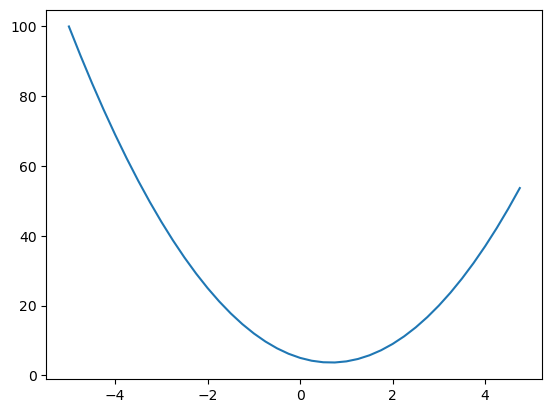

In [282]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [283]:
h = 0.000001
x = 2/3
(f(x+h) - f(x))/h

2.999378523327323e-06

In [284]:
# more complex

#inputs
a = 2.0
b = -3.0
c = 10.0

h = 0.0001

d1 = a*b + c

# bumped input by small amount
a+= h 
d2 = a*b + c 
print("d1",d1)
print("d2",d2)
print("slope", (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [285]:
# object

class Value:

    def __init__(self,data, _children=(), _op= '', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data + other.data, {self,other}, '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out


    def __mul__(self,other):
        other = other if isinstance (other, Value) else Value(other)#
        out = Value(self.data * other.data, {self,other}, '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward


        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other*(self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other
    
    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad = out.data * out.grad
        out._backward = _backward
        return out
    
    def backward(self):

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()




    
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0); f.label = 'f'
L = d*f; L.label = 'L'
print(d, d._prev, d._op, ',', d.label)

Value(data=4.0) {Value(data=-6.0), Value(data=10.0)} + , d


In [286]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir':'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it 
        dot.node(name = uid, label ="{ %s | data %.4f | grad%.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            # if this value a result of some operation, create op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

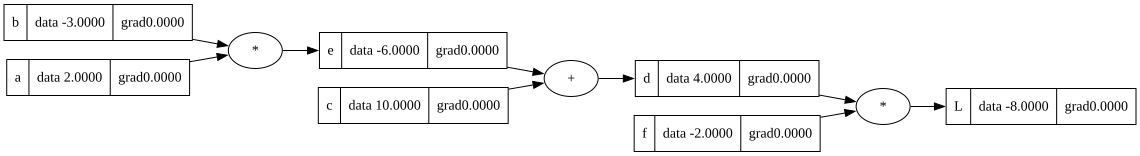

In [287]:
draw_dot(L)

#### Backpropogate Through Neuron - Example

In [288]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

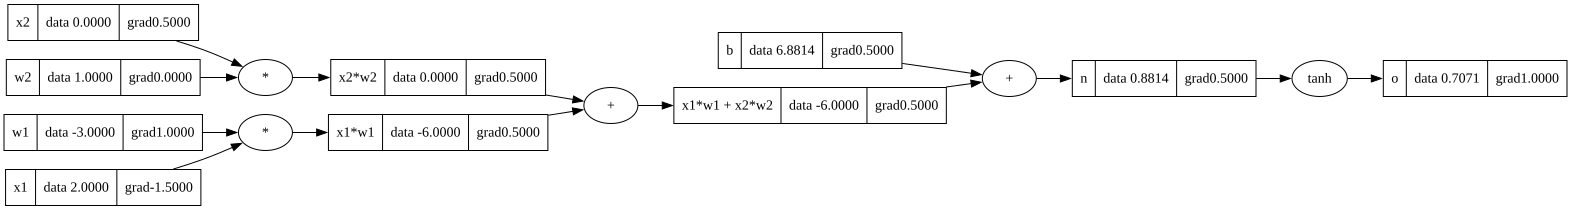

In [289]:
draw_dot(o)

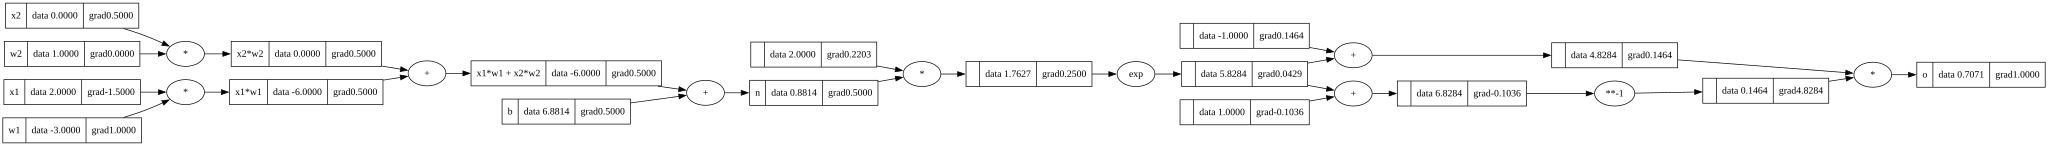

In [290]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e-1)/(e+1) ; o.label = 'o'
o.backward()
draw_dot(o)

In [291]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
-----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [292]:
import random

class Neuron:

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), start = self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [293]:
x = [2.0, 3.0, -1.0]
n = MLP(3,[4,4,1])
n(x)

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 5.0],
    [0.5, 1.0, 1.0],
    [1.0, 1.0,-1.0]
]

ys = [1.0,-1.0,-1.0,1.0] # desired targets



In [294]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip (ys, ypred))

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    for p in n.parameters():
        p.data += -0.05 * p.grad # minimizing loss

    print(k, loss.data)

0 6.450664589322536
1 1.9737245692863257
2 0.8243044665644981
3 0.49592147304248213
4 0.34568421140073996
5 0.2611805799044383
6 0.20772465812284313
7 0.17119810714153935
8 0.1448341534462298
9 0.12500889012310556
10 0.10961779003397665
11 0.09736049472087828
12 0.087393080539133
13 0.0791455363197775
14 0.0722198919361685
15 0.06633041857985057
16 0.06126701064942544
17 0.05687194226105974
18 0.05302464931771746
19 0.049631493643211747


In [295]:
loss

Value(data=0.049631493643211747)

In [296]:
ypred

[Value(data=0.8944875543310846),
 Value(data=-0.933126990147119),
 Value(data=-0.8598377281375609),
 Value(data=0.8800785442393559)]